# Lorenz96 — Lorenz (1996) Single-Scale and Two-Scale Atmospheric Models


## Overview

`Lorenz96` implements the periodic-ring atmospheric model of Lorenz (1996), with an optional fast-variable layer from Lorenz & Emanuel (1998). Three physical processes are encoded: quadratic advection, linear damping, and external forcing.

### Single-scale (`J=0`)

$$\frac{dX_i}{dt} = (X_{i+1} - X_{i-2})\,X_{i-1} - X_i + F, \qquad i = 0,\ldots,n-1$$

All indices cyclic mod $n$. For $F \gtrsim 5$ and $n = 40$ the system is chaotic; the canonical value is $F = 8$.

### Two-scale (`J>0`)

Each slow variable $X_k$ is coupled to $J$ fast variables $Y_{k,j}$:

$$\frac{dX_k}{dt} = (X_{k+1} - X_{k-2})\,X_{k-1} - X_k + F - \frac{hc}{b}\sum_{j=0}^{J-1} Y_{k,j}$$

$$\frac{dY_{k,j}}{dt} = -cb\,Y_{k,j+1}(Y_{k,j+2} - Y_{k,j-1}) - c\,Y_{k,j} + \frac{hc}{b}\,X_k$$

The parameter $c$ sets the timescale ratio: $Y$ evolves $c$ times faster than $X$.

### Parameters

| Name | Description | Default |
|---|---|---|
| `n` | Number of slow-scale variables | 40 |
| `J` | Fast variables per slow variable; `J=0` = single-scale | 0 |
| `F` | External forcing amplitude | 8.0 |
| `h` | Coupling coefficient X↔Y (two-scale only) | 1.0 |
| `b` | Y/X amplitude ratio (two-scale only) | 10.0 |
| `c` | Y/X timescale ratio (two-scale only) | 10.0 |

`F` accepts a `float`, callable `(t)` / `(t, state)`, or `cc.core.Forcing`.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import climatecritters as cc
from climatecritters.model_critters.lorenz import Lorenz96

rng = np.random.default_rng(42)   # fixed seed for reproducibility

## Single-Scale System

The single-scale system (`J=0`) is the simpler starting point. Random initial conditions on $[-1, 1]$ reach the chaotic attractor within a few time units. The canonical diagnostic is the **space-time diagram**: colour = $X_i$, rows = variable index, columns = time. Diagonal bands reveal westward-propagating wave packets.


In [2]:
n, F_canon = 40, 8.0
y0_ss = rng.uniform(-1, 1, n)

model_ss = Lorenz96(n=n, F=F_canon)
output_ss = model_ss.integrate(t_span=(0, 30), y0=y0_ss.tolist(),
                                method='rk4', dt=0.05)

t_ss = np.asarray(output_ss.time)
X_ss = np.column_stack([output_ss.state_variables[f'x{i}'] for i in range(n)])
print(f"X shape: {X_ss.shape}  ({X_ss.shape[0]} time steps \u00d7 {n} variables)")

X shape: (601, 40)  (601 time steps × 40 variables)


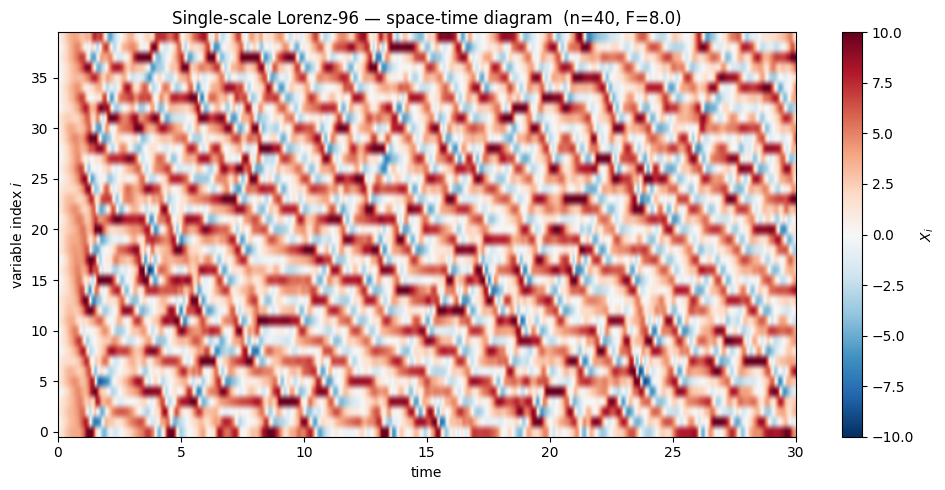

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(
    X_ss.T, aspect='auto', origin='lower',
    extent=[t_ss[0], t_ss[-1], -0.5, n - 0.5],
    cmap='RdBu_r', vmin=-10, vmax=10,
)
plt.colorbar(im, ax=ax, label='$X_i$')
ax.set_xlabel('time'); ax.set_ylabel('variable index $i$')
ax.set_title(f'Single-scale Lorenz-96 — space-time diagram  (n={n}, F={F_canon})')
plt.tight_layout(); plt.show()

**Reading the space-time diagram.** Each row is one of the $n=40$ model variables arranged around a ring; each column is a snapshot in time. Warm colours (red) indicate positive anomalies; cool (blue) indicate negative. The diagonal stripes are wave packets travelling around the ring: the tilt from lower-left to upper-right means each packet moves toward higher variable indices as time advances. Packets grow, break, and reform continuously — the hallmark of deterministic chaos. No two rows are in phase for long; coherence is lost within roughly one Lyapunov time ($\approx 0.6$–$1$ time units for $F=8$), which sets the limit of predictability.

The variables $X_i$ are sometimes interpreted as anomalies of some atmospheric quantity (e.g. vorticity or temperature) at equally spaced longitudes on a mid-latitude circle. The "westward" propagation of wave packets then corresponds to Rossby-wave-like behaviour — though Lorenz96 is a toy model and should not be over-interpreted physically.

### The `F` parameter

`F` is the external forcing amplitude. Low `F` (≲ 5) gives ordered, low-amplitude wave structures; high `F` gives fully developed chaos with larger excursions and shorter predictability. Below, `F=4` (weakly chaotic) is compared with `F=8` (canonical) using the same initial condition:


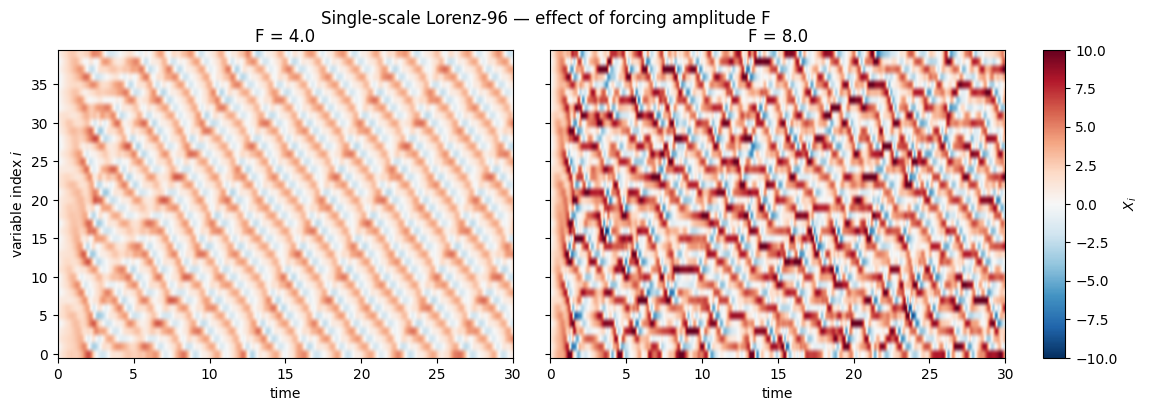

In [4]:
F_vals = [4.0, 8.0]

# gridspec: two equal plot columns + a narrow dedicated colorbar column
fig = plt.figure(figsize=(13, 4))
gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.12)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
cax = fig.add_subplot(gs[0, 2])

for ax, F_val in zip([ax0, ax1], F_vals):
    m = Lorenz96(n=n, F=F_val)
    out = m.integrate(t_span=(0, 30), y0=y0_ss.tolist(),
                      method='rk4', dt=0.05)
    t = np.asarray(out.time)
    X = np.column_stack([out.state_variables[f'x{i}'] for i in range(n)])
    im = ax.imshow(X.T, aspect='auto', origin='lower',
                   extent=[t[0], t[-1], -0.5, n - 0.5],
                   cmap='RdBu_r', vmin=-10, vmax=10)
    ax.set_xlabel('time'); ax.set_title(f'F = {F_val}')

ax0.set_ylabel('variable index $i$')
ax1.tick_params(labelleft=False)
fig.colorbar(im, cax=cax, label='$X_i$')
fig.suptitle('Single-scale Lorenz-96 — effect of forcing amplitude F')
plt.show()

**What changes with $F$.** At $F=4$ the waves are longer-lived: coherent stripes stretch across several time units before breaking, and the amplitude range is smaller (shading stays within roughly $\pm 5$). At $F=8$ the stripes break up much faster, excursions are larger (shading reaches $\pm 10$), and consecutive snapshots at the same $i$ look nearly uncorrelated after one or two time units. This compression of the predictability horizon is the practical meaning of "stronger forcing = more chaos" in this model. For $F \lesssim 5$ the system is only weakly chaotic or even periodic; the canonical $F=8$ sits well inside the fully turbulent regime.

## Two-Scale System

Setting `J > 0` activates the coupled fast-variable layer. Each slow variable $X_k$ drives $J$ fast variables $Y_{k,j}$, which feed back on $X_k$ through the coupling sink. With the default $c = 10$, $Y$ evolves ten times faster than $X$.

**The fast variables require a warmup.** Random initial conditions place the system far from the two-scale attractor; a short integration (≈ 10 time units) discards the transient before diagnostics are taken.

**Solver requirement:** use `method='rk4'` with a small fixed timestep `dt` and a coarser recording interval `si` (passed via `kwargs`). Adaptive solvers (RK45) call `dydt` at unpredictable sub-steps that corrupt the accumulated state for this model.


In [5]:
K, J_val = 36, 10
F_ts = 10.0

# IC: slow vars near the forcing level, fast vars near zero
y0_ts = np.concatenate([rng.standard_normal(K) + F_ts,
                         rng.standard_normal(K * J_val) * 0.01])

# --- warmup: reach the two-scale attractor ---
model_warm = Lorenz96(n=K, J=J_val, F=F_ts)
warmup = model_warm.integrate(t_span=(0, 10), y0=y0_ts.tolist(),
                               method='rk4', dt=0.005,
                               kwargs={'si': 0.05})

# Extract the final state as the production IC
y0_warm = np.array(
    [warmup.state_variables[f'x{k}'][-1] for k in range(K)] +
    [warmup.state_variables[f'y{j}'][-1] for j in range(K * J_val)]
)

# --- production run: si=0.005 resolves Y dynamics (timescale ~ 1/c = 0.1) ---
model_ts = Lorenz96(n=K, J=J_val, F=F_ts)
output_ts = model_ts.integrate(t_span=(0, 20), y0=y0_warm.tolist(),
                                method='rk4', dt=0.005,
                                kwargs={'si': 0.005})

t_ts = np.asarray(output_ts.time)
X_ts = np.column_stack([output_ts.state_variables[f'x{k}'] for k in range(K)])
Y_ts = np.column_stack([output_ts.state_variables[f'y{j}'] for j in range(K * J_val)])
print(f"X shape: {X_ts.shape}  (slow)")
print(f"Y shape: {Y_ts.shape}  (fast)")

X shape: (4001, 36)  (slow)
Y shape: (4001, 360)  (fast)


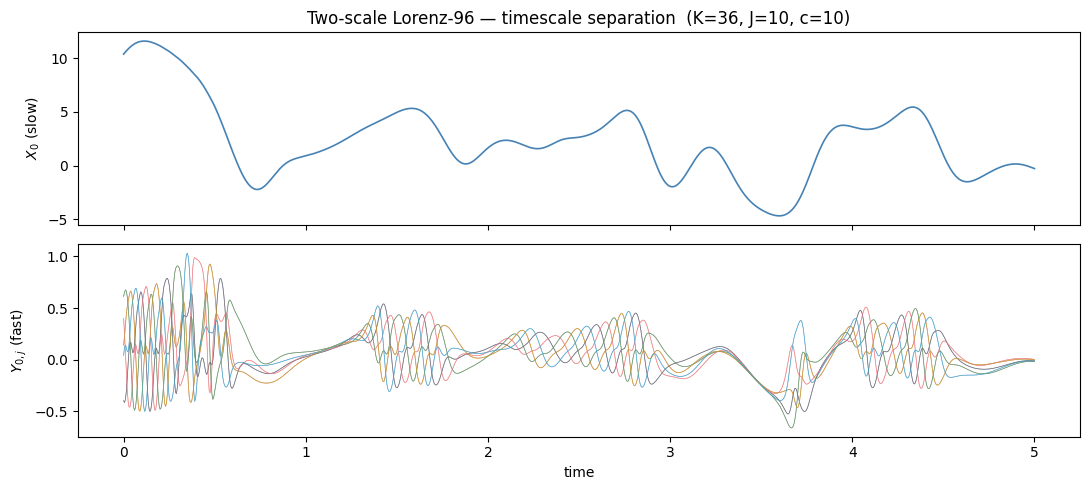

In [6]:
# Zoom to first 5 time units to make individual Y oscillations visible
mask = t_ts <= 5.0
Y_block0 = Y_ts[:, :J_val]   # Y_{0,j} for j = 0..J-1

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

axes[0].plot(t_ts[mask], X_ts[mask, 0], lw=1.2, color='steelblue')
axes[0].set_ylabel('$X_0$ (slow)')
axes[0].set_title(f'Two-scale Lorenz-96 — timescale separation  (K={K}, J={J_val}, c=10)')

# J fast variables attached to X_0; each oscillates ~10x faster than X
for j in range(J_val):
    axes[1].plot(t_ts[mask], Y_block0[mask, j], lw=0.5, alpha=0.7)
axes[1].set_ylabel('$Y_{0,j}$ (fast)')
axes[1].set_xlabel('time')

plt.tight_layout(); plt.show()

**What the two panels show.** The upper panel ($X_0$) is the slow "resolved" variable — it evolves on order-1 time units and looks like a typical L96 trajectory. The lower panel shows the $J=10$ fast variables $Y_{0,j}$ attached to $X_0$. They oscillate roughly $c=10$ times faster than $X_0$ and with amplitudes scaled by $1/b = 0.1$ relative to the slow scale. Their net effect on $X_0$ enters as the coupling sink $-\frac{hc}{b}\sum_j Y_{0,j}$, which acts like a stochastic sub-grid drag — reducing the effective forcing seen by the slow variables.

The two-scale system is the standard benchmark for **data assimilation** and **parameterisation** research: the $X$ variables represent the "truth" that a model must track, while the $Y$ variables represent unresolved processes that a coarser model would need to parameterise.

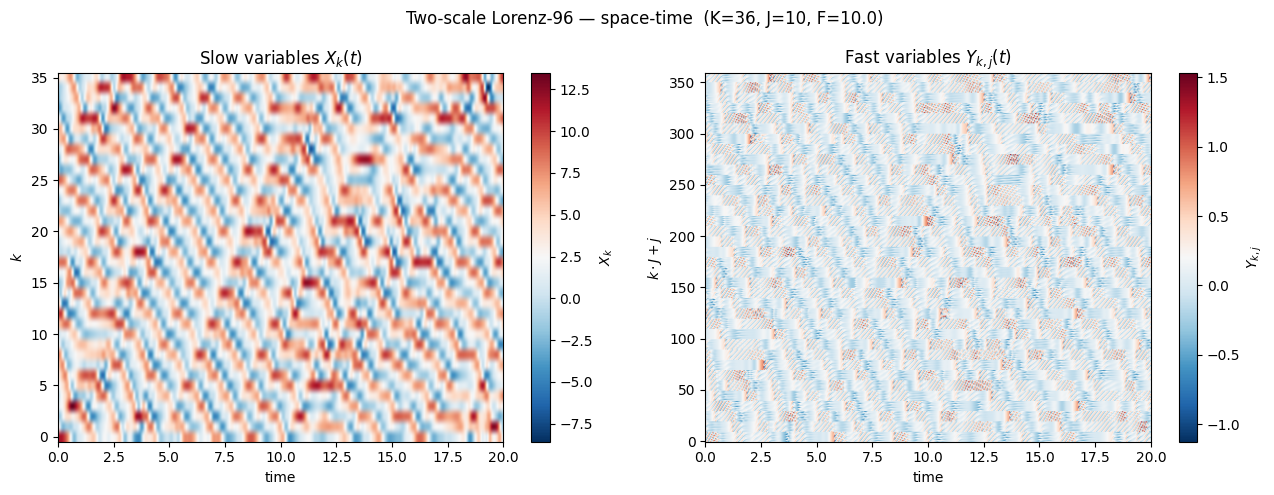

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(
    X_ts.T, aspect='auto', origin='lower',
    extent=[t_ts[0], t_ts[-1], -0.5, K - 0.5],
    cmap='RdBu_r',
)
plt.colorbar(im0, ax=axes[0], label='$X_k$')
axes[0].set_xlabel('time'); axes[0].set_ylabel('$k$')
axes[0].set_title('Slow variables $X_k(t)$')

im1 = axes[1].imshow(
    Y_ts.T, aspect='auto', origin='lower',
    extent=[t_ts[0], t_ts[-1], -0.5, K * J_val - 0.5],
    cmap='RdBu_r',
)
plt.colorbar(im1, ax=axes[1], label='$Y_{k,j}$')
axes[1].set_xlabel('time'); axes[1].set_ylabel('$k \\cdot J + j$')
axes[1].set_title('Fast variables $Y_{k,j}(t)$')

fig.suptitle(f'Two-scale Lorenz-96 — space-time  (K={K}, J={J_val}, F={F_ts})')
plt.tight_layout(); plt.show()

**Comparing the two space-time diagrams.** The left panel ($X_k$) looks qualitatively like the single-scale diagram — propagating wave packets on the slow timescale. The right panel ($Y_{k,j}$) has $K \times J = 360$ rows. They are ordered as $Y_{0,0},\ldots,Y_{0,J-1},\,Y_{1,0},\ldots$ so every $J=10$ rows corresponds to a new host variable $X_k$; the repeating block structure is visible as horizontal banding every 10 rows. Within each block the $J$ fast variables share the same slow-scale envelope (inherited from $X_k$) but carry rapid fine-scale oscillations. The Y field consequently looks like a "textured" version of X: the large-scale wave pattern is still faintly visible, but the dominant visual impression is rapid, small-scale variability.

## Solver notes

**Single-scale (`J=0`):** RK45 (adaptive) or `rk4` (fixed step) both work. `dt=0.05` is adequate for space-time diagnostics at $F=8$.

**Two-scale (`J>0`):** always use `method='rk4'` with explicit `dt` and `si`. Adaptive solvers call `dydt` at sub-step evaluations that corrupt the accumulated state history for this model.
```python
output = model.integrate(t_span=..., y0=..., method='rk4',
                         dt=0.005, kwargs={'si': 0.005})
```
- `dt`: integration timestep — keep ≤ 0.005 for the two-scale system to resolve fast-variable dynamics
- `si`: recording interval — set equal to `dt` to capture all Y oscillations, or larger to downsample

**Accessing Y for variable k:** `output.state_variables[f'y{k*J + j}']` for $j = 0,\ldots,J-1$.

**Warmup is required for the two-scale system.** Random initial conditions placed far from the attractor take ≈ 5–10 time units to equilibrate. Always discard a warmup run before taking statistics or diagnostics.
